In [3]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import matplotlib.text


In [4]:
import sys
from atlasopenmagic import install_from_environment
install_from_environment

<function atlasopenmagic.utils.install_from_environment(*packages: str | None, environment_file: str | None = None) -> None>

In [5]:
import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 465.69datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [6]:
skim = '4lep'
files_list = atom.get_urls('345060', skim, protocol = 'https', cache=True)

In [7]:
analysis = uproot.open(files_list[0] +':analysis')
attributes = ['pt','eta','phi','e','charge','flavor','tight']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
leps = analysis.arrays(attributes, aliases = aliases_dict)

In [8]:
leps

<Array [{pt: [13.4, ...], eta: ..., ...}, ...] type='424880 * {pt: var * fl...'>

In [9]:
leps = leps[np.argsort(leps.pt, axis=1)][:,::-1][:,:4]

In [26]:
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

vecs = np.array([leps.e, px, py, pz, leps.charge, leps.flavor, leps.tight])

In [27]:
Z0 = vecs[:, :, 0] + vecs[:, :, 1]
Z1 = vecs[:, :, 0] + vecs[:, :, 2]
Z2 = vecs[:, :, 0] + vecs[:, :, 3]
Z3 = vecs[:, :, 1] + vecs[:, :, 2]
Z4 = vecs[:, :, 1] + vecs[:, :, 3]
Z5 = vecs[:, :, 2] + vecs[:, :, 3]

In [28]:
Zs = np.array([Z0, Z1, Z2, Z3, Z4, Z5])

In [29]:
Z_charge_cut = Zs[:, 4] == 0
Z_flavor_cut = (Zs[:,5] == 22 )|( Zs[:,3] == 26)
Z_tight_cut = Zs[:, 6] == 2

In [30]:
Z_mass = np.sqrt(np.abs(Zs[:,0,:]**2-Zs[:,1,:]**2-Zs[:,2,:]**2-Zs[:,3,:]**2))

In [31]:
cut = Z_charge_cut & Z_flavor_cut & Z_tight_cut
cut_Z_mass = np.copy(Z_mass)
cut_Z_mass[~cut]=0

In [32]:
Z_masses = np.ndarray.flatten(cut_Z_mass)
Z_masses = Z_masses[Z_masses != 0]

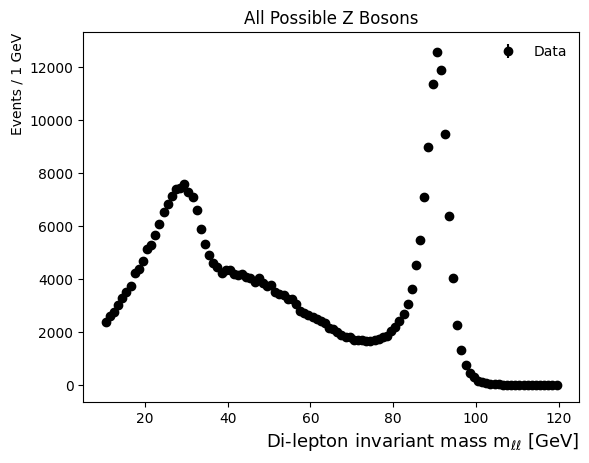

In [33]:
xmin = 10
xmax = 120

bin_width = 1
bin_edges = np.arange(start=xmin, stop=xmax+bin_width, step=bin_width)
bin_centers = bin_edges[:-1]+bin_width/2

counts, _ = np.histogram(Z_masses, bins = bin_edges)
count_errors = np.sqrt(counts)

axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Di-lepton invariant mass $\mathrm{m_{\ell\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('All Possible Z Bosons')
axs.legend(frameon = False)
plt.show()